In [13]:
import pandas as pd
import numpy as np
from collections import Counter
from nltk.util import ngrams
import spacy

df = pd.read_excel('/content/drive/MyDrive/Dataset.xlsx')

df['wordCount'] = df['text'].astype(str).apply(lambda x: len(x.split()))

df = df[(df['wordCount'] >= 300) & (df['wordCount'] <= 400)].copy()

dfHuman = df[(df['isHuman'] == 1) & (df['source'] == 'scientific research')].head(20)
dfgpt4 = df[(df['isHuman'] == 0) & (df['source'] == 'gpt-3')].head(20)

nlp = spacy.load("en_core_web_sm")

dfHuman['tokens'] = dfHuman['text'].apply(lambda x: nlp(x))
dfgpt4['tokens'] = dfgpt4['text'].apply(lambda x: nlp(x))

df = pd.concat([dfHuman, dfgpt4], ignore_index=True)

df.to_excel('./DataSetFiltered.xlsx', index=False)

In [14]:
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import math

df = pd.read_excel('./DataSetFiltered.xlsx')

df["group"] = df.apply(lambda row: "Human" if row["isHuman"] == 1 else row['source'], axis=1)






In [15]:
def visualiseNgramRepetition(df, featureName):

  plt.figure(figsize=(12,6))
  sns.boxplot(
      data=df,
      x="group",
      y=featureName,
      palette="pastel"
  )

  plt.xlabel("Group")
  plt.ylabel(featureName)
  plt.xticks(rotation=45)
  plt.tight_layout()
  plt.show()

def ngramRepetition(text, n):
  tokens = text.split()
  if len(tokens) < n:
      return 0

  ngrams = [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]
  total = len(ngrams)
  unique = len(set(ngrams))

  return 1 - (unique / total)

df["bigramRepetition"] = df["text"].apply(lambda x: ngramRepetition(x, n=2))

df["trigramRepetition"] = df["text"].apply(lambda x: ngramRepetition(x, n=3))

df["quadgramRepetition"] = df["text"].apply(lambda x: ngramRepetition(x, n=4))



In [16]:
def ngramEntropy(text, n):
  tokens = text.split()
  if len(tokens) < n:
      return 0

  ngrams = [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]

  counts = Counter(ngrams)

  total = sum(counts.values())

  entropy = 0
  for count in counts.values():
      p = count / total
      entropy += -p * math.log2(p)

  return entropy

def visualiseNgramEntropy(df, featureName):

  plt.figure(figsize=(10,6))
  sns.boxplot(
      data=df,
      x="group",
      y=featureName,
      palette="pastel"
  )

  plt.title(f"{featureName} Distribution")
  plt.xlabel("Text Source")
  plt.ylabel(featureName)
  plt.tight_layout()
  plt.show()


df["bigramEntropy"] = df["text"].apply(lambda x: ngramEntropy(x, n=2))

df["trigramEntropy"] = df["text"].apply(lambda x: ngramEntropy(x, n=3))

df["quadgramEntropy"] = df["text"].apply(lambda x: ngramEntropy(x, n=4))




In [17]:
def calculateSentenceLengthVariation(text):
    doc = nlp(text)

    sentences = list(doc.sents)

    sentenceLengths = [len(sent) for sent in sentences]

    meanLength = np.mean(sentenceLengths)
    stdLength = np.std(sentenceLengths)

    if meanLength == 0:
        return 0

    coefficientVariation = stdLength / meanLength
    return coefficientVariation

def visualiseSentenceLengthVariation(df):
    plt.figure(figsize=(12,6))
    sns.boxplot(
        data=df,
        x="group",
        y="sentenceLengthVariations",
        palette="pastel"
    )

    plt.xlabel("Group")
    plt.ylabel("coefficientVariation")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

df["sentenceLengthVariations"] = df["text"].apply(calculateSentenceLengthVariation)

In [18]:
def calculateLexicalBurstiness(text):
    words = text.lower().split()
    if len(words) < 2:
        return 0

    wordCounts = Counter(words)
    frequencies = list(wordCounts.values())

    if len(frequencies) < 2:
        return 0

    meanFrequency = np.mean(frequencies)
    stdFrequency = np.std(frequencies)

    if meanFrequency == 0:
        return 0

    return stdFrequency / meanFrequency

def visualiseLexicalBurstiness(df):

  plt.figure(figsize=(10,6))
  sns.boxplot(
      data=df,
      x="group",
      y="lexicalBurstiness",
      palette="pastel"
  )

  plt.title("Lexical Burstiness Boxplot")
  plt.xlabel("Group")
  plt.ylabel("Lexical Burstiness")
  plt.xticks(rotation=45)
  plt.tight_layout()
  plt.show()

df['lexicalBurstiness'] = df['text'].apply(calculateLexicalBurstiness)


/tmp/ipython-input-3296008228.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


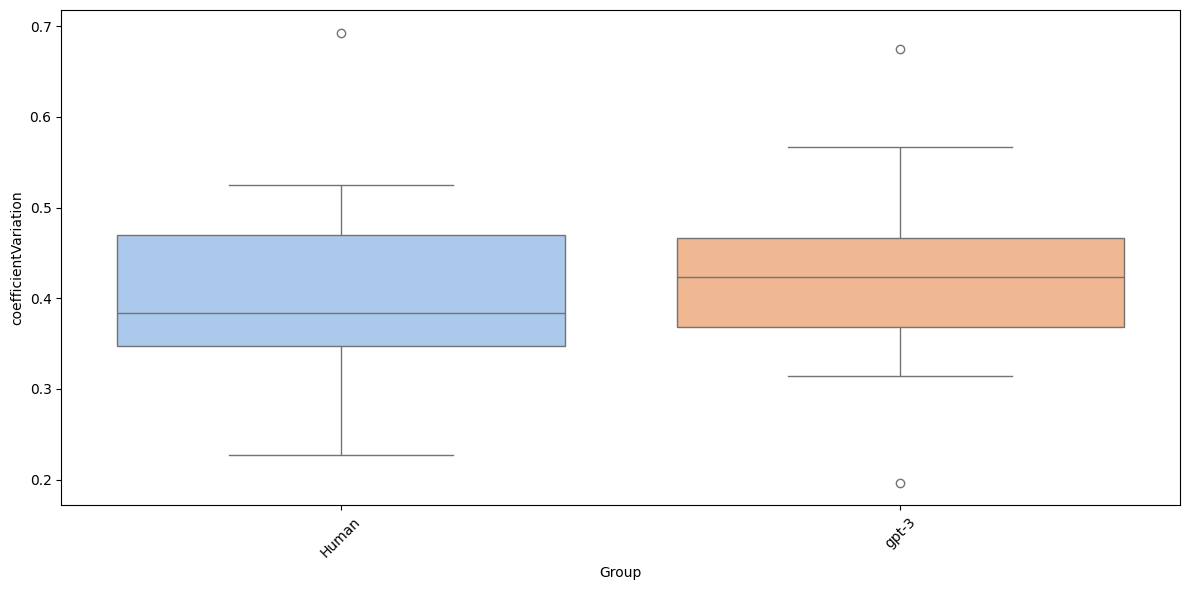

/tmp/ipython-input-638942627.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


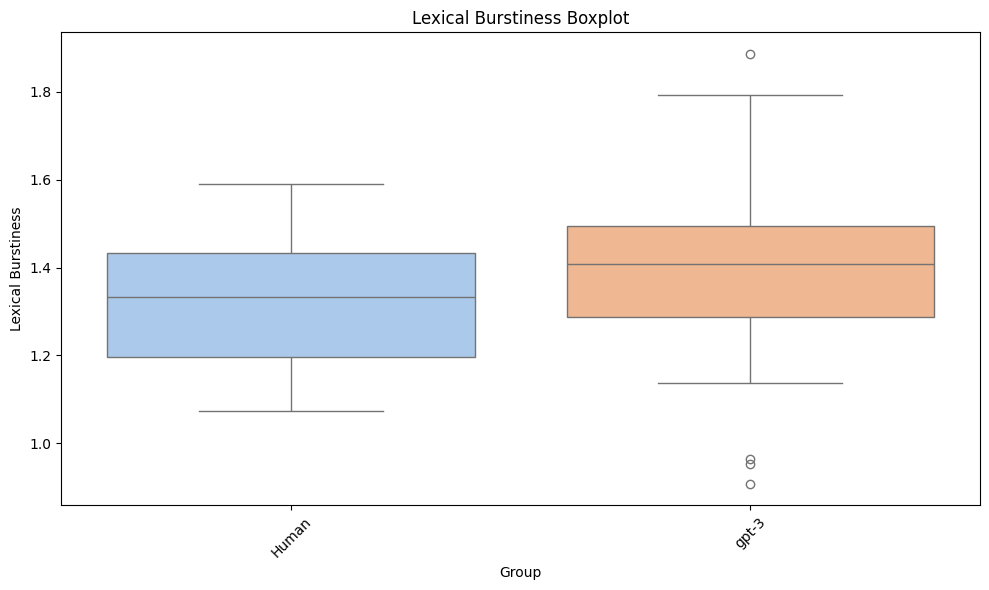

/tmp/ipython-input-3850880127.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


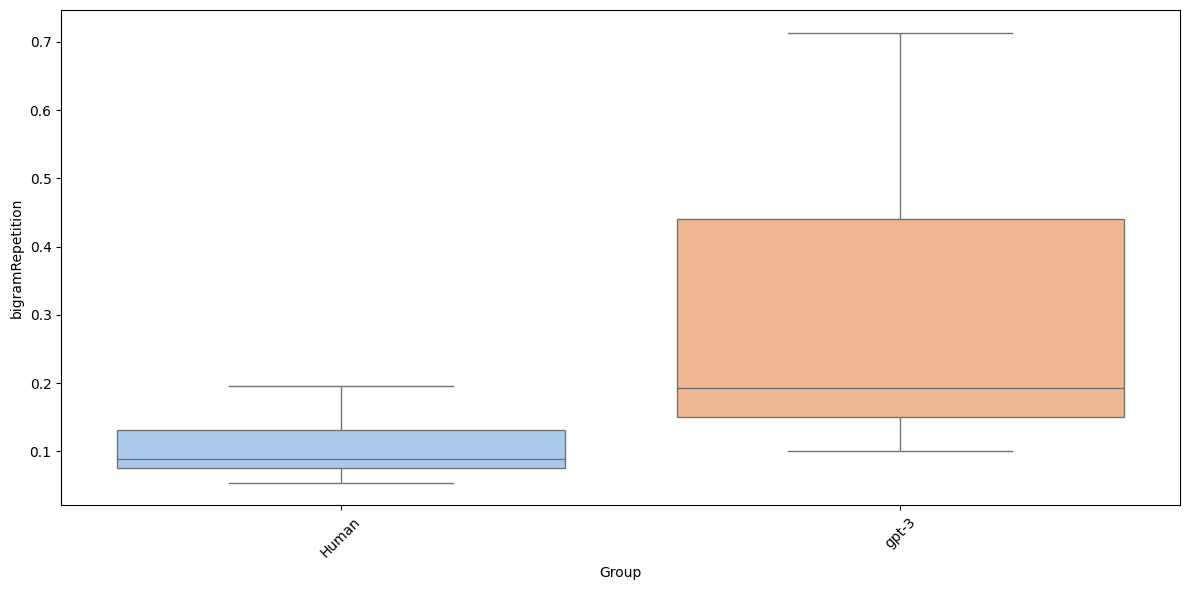

/tmp/ipython-input-3850880127.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


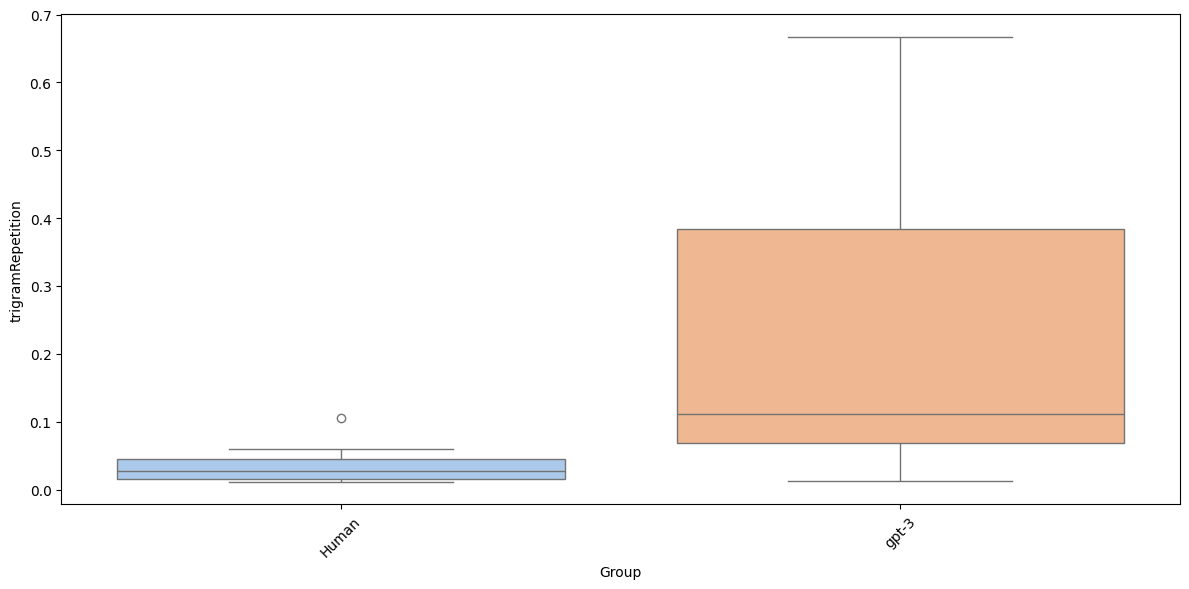

/tmp/ipython-input-3850880127.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


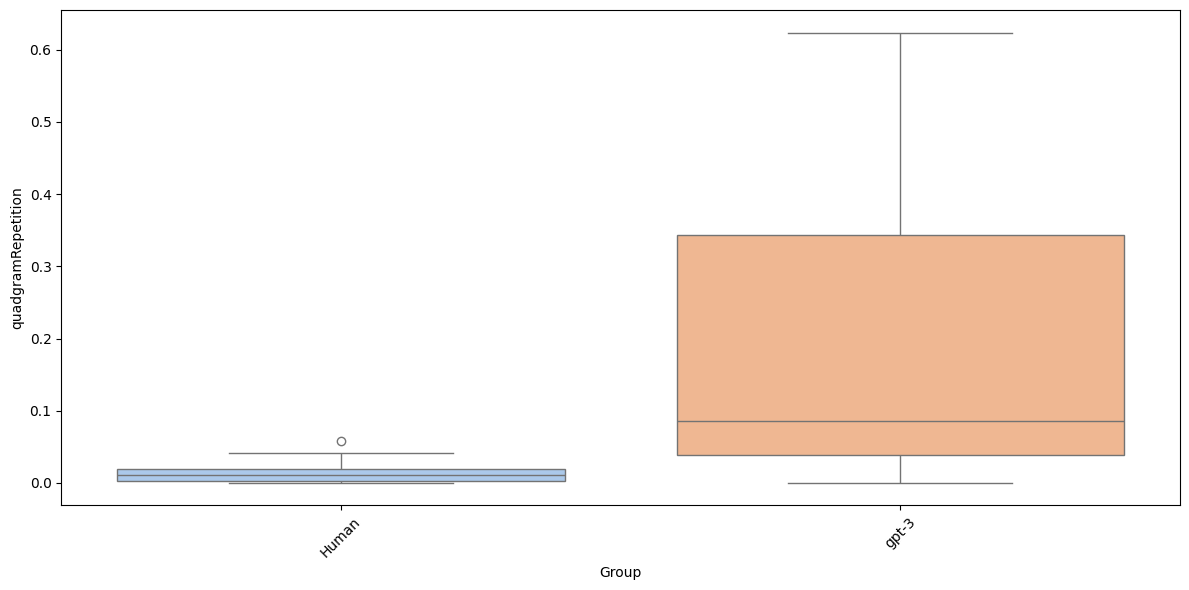

/tmp/ipython-input-3319169182.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


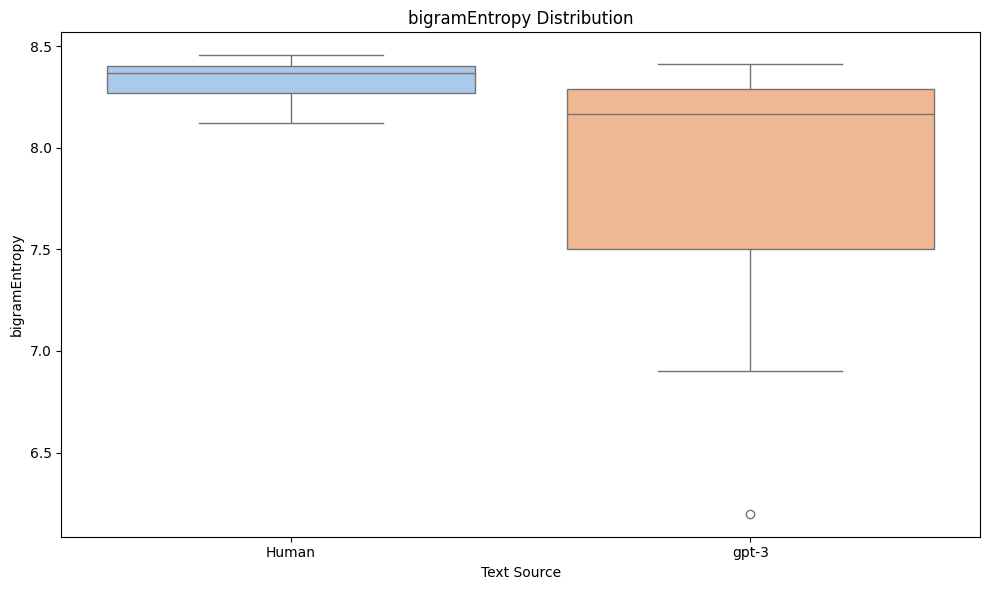

/tmp/ipython-input-3319169182.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


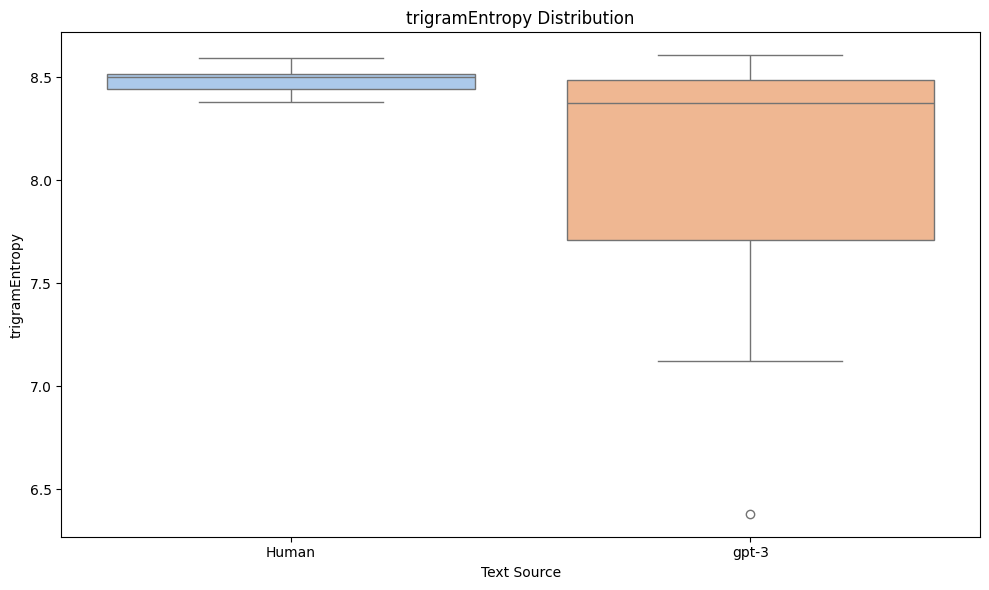

/tmp/ipython-input-3319169182.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


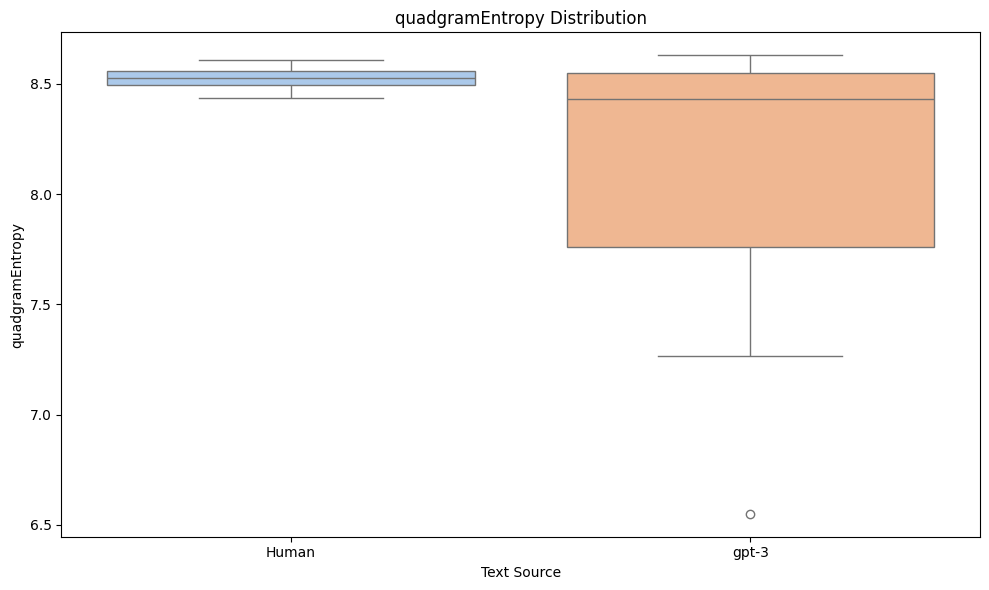

In [19]:
visualiseSentenceLengthVariation(df)
visualiseLexicalBurstiness(df)
visualiseNgramRepetition(df, "bigramRepetition")
visualiseNgramRepetition(df, "trigramRepetition")
visualiseNgramRepetition(df, "quadgramRepetition")
visualiseNgramEntropy(df, "bigramEntropy")
visualiseNgramEntropy(df, "trigramEntropy")
visualiseNgramEntropy(df, "quadgramEntropy")


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

featureCols = [
    "bigramRepetition",
    "trigramRepetition",
    "quadgramRepetition",
    "bigramEntropy",
    "trigramEntropy",
    "quadgramEntropy",
    "sentenceLengthVariations",
    "lexicalBurstiness"
]

X = df[featureCols]
y = df['isHuman']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

clf = RandomForestClassifier()
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)


print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         5

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8

